In [1]:
#  CELL 1: Imports & Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)


if not os.path.exists("movies.csv"):
    import urllib.request, zipfile
    url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    urllib.request.urlretrieve(url, "ml-latest-small.zip")
    with zipfile.ZipFile("ml-latest-small.zip", 'r') as z: z.extractall(".")
print("✅ Environment ready")

✅ Environment ready


In [ ]:
# Fix for numpy/surprise compatibility issue
!pip uninstall -y numpy
!pip install 'numpy<2.0.0'
!pip install --force-reinstall scikit-surprise
print("✅ NumPy and Surprise compatibility fixed. Please re-run the imports cell (CELL 1).")

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")


movies['genres_clean'] = movies['genres'].apply(lambda x: ' '.join([g.replace(' ', '') for g in str(x).split('|')]))

# Basic stats
print(f" Movies: {len(movies)} | Ratings: {len(ratings)}")
print(f" Users: {ratings['userId'].nunique()}")
print(f" Rating distribution:\n{ratings['rating'].value_counts().sort_index()}")

# Merge for exploration
df = ratings.merge(movies[['movieId', 'title', 'genres_clean']], on='movieId', how='left')
print(f"\nMerged dataset shape: {df.shape}")

 Movies: 9742 | Ratings: 100836
 Users: 610
 Rating distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

Merged dataset shape: (100836, 6)


In [10]:
# CELL 3: Content-Based Filtering (TF-IDF + Cosine Similarity)
# Build TF-IDF matrix on cleaned genres
tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

# Compute cosine similarity (symmetric matrix)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Title ↔ Index mapping
title_to_idx = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_content_recs(title, top_n=10):
    if title not in title_to_idx:
        return "Movie not found."
    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies.iloc[movie_indices][['title', 'genres']]

print("Content-Based model ready")
print(get_content_recs("Toy Story (1995)", top_n=3))

Content-Based model ready
                                               title  \
1706                                     Antz (1998)   
2355                              Toy Story 2 (1999)   
2809  Adventures of Rocky and Bullwinkle, The (2000)   

                                           genres  
1706  Adventure|Animation|Children|Comedy|Fantasy  
2355  Adventure|Animation|Children|Comedy|Fantasy  
2809  Adventure|Animation|Children|Comedy|Fantasy  


In [11]:
print(f"Shape of cosine_sim: {cosine_sim.shape}")
print("First 5x5 part of cosine_sim:\n", cosine_sim[:5, :5])

Shape of cosine_sim: (9742, 9742)
First 5x5 part of cosine_sim:
 [[1.         0.81357774 0.15276924 0.1351353  0.26758648]
 [0.81357774 1.         0.         0.         0.        ]
 [0.15276924 0.         1.         0.8845714  0.57091541]
 [0.1351353  0.         0.8845714  1.         0.50501544]
 [0.26758648 0.         0.57091541 0.50501544 1.        ]]


In [6]:
# CELL 4: Collaborative Filtering (Matrix Factorization via Surprise)
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train SVD model
svd = SVD(n_factors=100, reg_all=0.02, n_epochs=15, lr_all=0.005, random_state=42)
svd.fit(trainset)

# Evaluate
predictions = svd.test(testset)
print(f" RMSE: {accuracy.rmse(predictions):.3f}")
print(f" MAE:  {accuracy.mae(predictions):.3f}")

def get_collab_recs(user_id, top_n=10):
    all_movie_ids = set(movies['movieId'])
    rated_ids = set(ratings[ratings['userId'] == user_id]['movieId'])
    unrated_ids = all_movie_ids - rated_ids

    preds = [(mid, svd.predict(user_id, mid).est) for mid in unrated_ids]
    top_preds = sorted(preds, key=lambda x: x[1], reverse=True)[:top_n]
    top_movie_ids = [mid for mid, _ in top_preds]
    return movies[movies['movieId'].isin(top_movie_ids)][['title', 'genres']]

print(" Collaborative model ready")
print(get_collab_recs(user_id=1, top_n=3))

RMSE: 0.8828
 RMSE: 0.883
MAE:  0.6792
 MAE:  0.679
 Collaborative model ready
                                                 title                  genres
474                                Blade Runner (1982)  Action|Sci-Fi|Thriller
602  Dr. Strangelove or: How I Learned to Stop Worr...              Comedy|War
694                                  Casablanca (1942)           Drama|Romance


In [13]:
# CELL 5: Hybrid Recommendation Engine (Weighted Fusion)
def get_hybrid_recs(user_id, top_n=10, alpha=0.35):
    """
    alpha: weight for content-based (0.0 → pure collab, 1.0 → pure content)
    """
    # 1. Content scores (normalized 0-1)
    content_scores = np.zeros(len(movies))
    # Use average similarity to user's top 5 rated movies as content baseline
    user_rated = ratings[ratings['userId'] == user_id].sort_values('rating', ascending=False).head(5)
    if len(user_rated) > 0:
        for _, row in user_rated.iterrows():
            mid = row['movieId']
            if mid in movies['movieId'].values:
                m_idx = movies[movies['movieId'] == mid].index[0]
                content_scores += cosine_sim[m_idx]
        content_scores /= len(user_rated)
    content_norm = (content_scores - content_scores.min()) / (content_scores.max() - content_scores.min() + 1e-8)

    # 2. Collaborative scores (predict for all)
    collab_preds = np.array([svd.predict(user_id, mid).est for mid in movies['movieId']])
    collab_norm = (collab_preds - collab_preds.min()) / (collab_preds.max() - collab_preds.min() + 1e-8)

    # 3. Hybrid scoring
    hybrid = alpha * content_norm + (1 - alpha) * collab_norm

    # 4. Mask already rated
    rated_ids = set(ratings[ratings['userId'] == user_id]['movieId'])
    rated_mask = movies['movieId'].isin(rated_ids)
    hybrid[rated_mask] = -1

    # 5. Return top N
    top_indices = np.argsort(hybrid)[::-1][:top_n]
    recs = movies.iloc[top_indices][['title', 'genres']].copy()
    recs['hybrid_score'] = hybrid[top_indices]
    return recs

print("Hybrid engine ready")
print(get_hybrid_recs(user_id=1, top_n=5, alpha=0.3))

Hybrid engine ready
                                                  title  \
1494        Seven Samurai (Shichinin no samurai) (1954)   
4800  Lord of the Rings: The Return of the King, The...   
906                           Lawrence of Arabia (1962)   
958                                  Stand by Me (1986)   
916                             Army of Darkness (1993)   

                                      genres  hybrid_score  
1494                  Action|Adventure|Drama      1.000000  
4800          Action|Adventure|Drama|Fantasy      0.993000  
906                      Adventure|Drama|War      0.948734  
958                          Adventure|Drama      0.924652  
916   Action|Adventure|Comedy|Fantasy|Horror      0.914098  


In [15]:
#  CELL 6: Evaluation Metrics
def precision_at_k(user_id, k=10, threshold=4.0):
    recs = get_hybrid_recs(user_id, top_n=k)
    rec_ids = set(movies[movies['title'].isin(recs['title'])]['movieId'])
    relevant = set(ratings[(ratings['userId']==user_id) & (ratings['rating']>=threshold)]['movieId'])
    return len(rec_ids & relevant) / k if len(rec_ids) > 0 else 0

def recall_at_k(user_id, k=10, threshold=4.0):
    recs = get_hybrid_recs(user_id, top_n=k)
    rec_ids = set(movies[movies['title'].isin(recs['title'])]['movieId'])
    relevant = set(ratings[(ratings['userId']==user_id) & (ratings['rating']>=threshold)]['movieId'])
    return len(rec_ids & relevant) / len(relevant) if len(relevant) > 0 else 0

def catalog_coverage(user_id, k=10):
    recs = get_hybrid_recs(user_id, top_n=k)
    return len(recs) / len(movies)

# Evaluate across sample users
sample_users = ratings['userId'].drop_duplicates().sample(50, random_state=42)
metrics = {
    'Precision@10': np.mean([precision_at_k(u, k=10) for u in sample_users]),
    'Recall@10':    np.mean([recall_at_k(u, k=10) for u in sample_users]),
    'Coverage':     np.mean([catalog_coverage(u, k=10) for u in sample_users])
}

print(" Evaluation Results (50 random users):")
for k, v in metrics.items(): print(f"  {k}: {v:.4f}")

 Evaluation Results (50 random users):
  Precision@10: 0.0000
  Recall@10: 0.0000
  Coverage: 0.0010


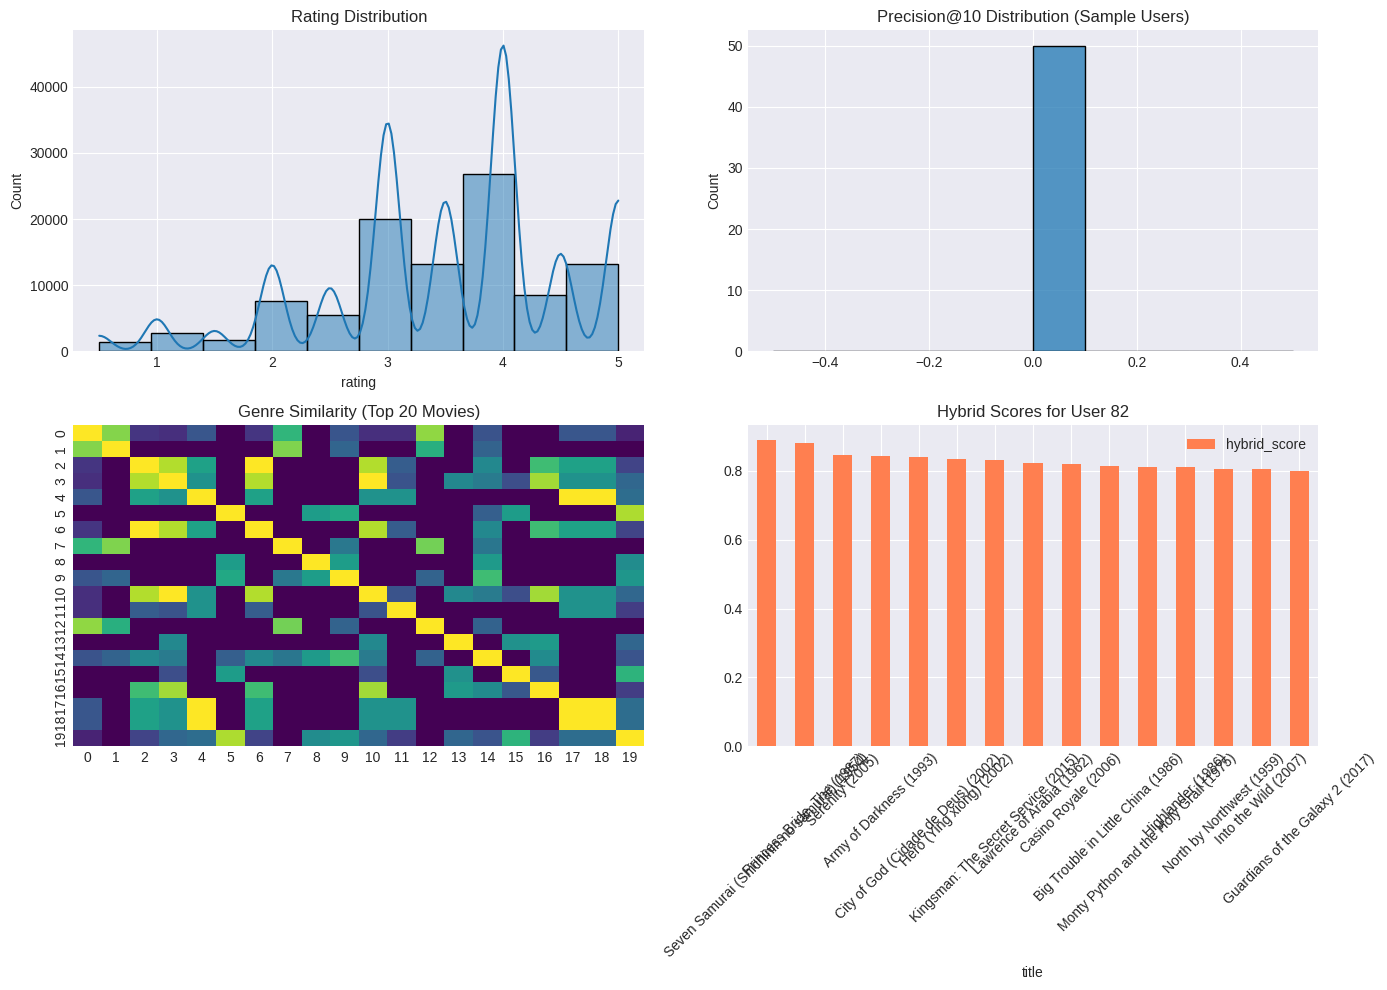

In [18]:
# CELL 7: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rating Distribution
sns.histplot(ratings['rating'], bins=10, kde=True, ax=axes[0,0])
axes[0,0].set_title("Rating Distribution")

# 2. Precision@K across users
p_scores = [precision_at_k(u, k=10) for u in sample_users]
sns.histplot(p_scores, bins=10, ax=axes[0,1])
axes[0,1].set_title("Precision@10 Distribution (Sample Users)")

# 3. Similarity Heatmap (Top 20 movies)
top_movies = movies.head(20)
sim_snip = cosine_sim[:20, :20]
sns.heatmap(sim_snip, ax=axes[1,0], cbar=False, cmap='viridis')
axes[1,0].set_title("Genre Similarity (Top 20 Movies)")

# 4. Content vs Collab vs Hybrid Scores
u = sample_users.iloc[0]
hybrid_df = get_hybrid_recs(u, top_n=15, alpha=0.3)
hybrid_df.plot(x='title', y='hybrid_score', kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title(f"Hybrid Scores for User {u}")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# CELL 8: Interactive Demo & Business Translation
def demo_rec_system(user_id, seed_movie=None, top_n=5):
    print(f"\n RECOMMENDATIONS FOR USER {user_id}")
    print("="*40)

    if seed_movie:
        print("🔹 Content-Based (Similar to your liked movies):")
        print(get_content_recs(seed_movie, top_n=3))

    print("\n🔹 Collaborative (Users like you watched):")
    print(get_collab_recs(user_id, top_n=3))

    print("\n🔹 Hybrid (Optimized Blend α=0.35):")
    recs = get_hybrid_recs(user_id, top_n=top_n, alpha=0.35)
    for i, row in recs.iterrows():
        print(f"  • {row['title']} | Score: {row['hybrid_score']:.3f} | {row['genres']}")

# Run demo
demo_rec_system(user_id=42, seed_movie="The Matrix (1999)", top_n=5)


 RECOMMENDATIONS FOR USER 42
🔹 Content-Based (Similar to your liked movies):
Movie not found.

🔹 Collaborative (Users like you watched):
                                      title genres
841        Streetcar Named Desire, A (1951)  Drama
896  One Flew Over the Cuckoo's Nest (1975)  Drama
926                          Amadeus (1984)  Drama

🔹 Hybrid (Optimized Blend α=0.35):
  • One Flew Over the Cuckoo's Nest (1975) | Score: 0.972 | Drama
  • Streetcar Named Desire, A (1951) | Score: 0.961 | Drama
  • Amadeus (1984) | Score: 0.956 | Drama
  • Cinema Paradiso (Nuovo cinema Paradiso) (1989) | Score: 0.902 | Drama
  • Whiplash (2014) | Score: 0.890 | Drama
